# Part 2: randomized benchmarking under both correlated and uncorrelated  noise

Part 1 characterised how an *idle* qubit loses coherence. This notebook asks the operational question that follows: how good is a gate? — and whether the standard way of measuring that survives the noise this hardware actually has.

## Why randomized benchmarking

The direct approach, process tomography, reconstructs the full channel of a gate. It is expensive (12 real parameters for one qubit) and, more seriously, contaminated: the measurement is corrupted by state-preparation and readout errors (SPAM), which cannot be separated from the gate error within the protocol.

Randomized benchmarking (Magesan, Gambetta & Emerson, PRA **85**, 042311 (2012)) avoids both. One applies a sequence of $m$ gates drawn at random from the Clifford group ( the 24 single-qubit unitaries that map Pauli operators to Pauli operators, i.e. the rotations by multiples of $90°$ about the coordinate and diagonal axes of the Bloch sphere) followed by the single Clifford inverting their product. The survival probability is the probability of measuring the initial state at the end. Without noise it equals 1 for any $m$, by construction. With noise it decays as

$$P(m) = A\,p^m + B$$

Here $p$ is the depolarising parameter: the fraction of the Bloch vector's length retained per gate, so $p=1$ is a perfect gate and $p=1/3$ complete dephasing. $A$ and $B$ absorb the state-preparation and measurement errors. The error rate therefore lives in $p$ alone, and the quantity of interest is insensitive to SPAM. This is the property that makes RB the standard characterisation tool.

## Why the decay is a single exponential

An arbitrary error is not depolarising. The noise here, for instance, is purely $Z$ dephasing, which acts very differently along $x$ than along $z$. Randomizing over Cliffords fixes this. Averaging a channel over a group is called twirling, and because the Clifford group is a unitary 2-design (it reproduces the average over all unitaries for any quantity quadratic in the channel), the twirl of any channel is a depolarising channel: one that shrinks the Bloch vector by the same factor $p$ in every direction, leaving the maximally mixed state untouched.

Direction-independent errors then compound multiplicatively, hence $p^m$, and $B = 1/2$ is the maximally mixed fixed point. The average gate fidelity — the overlap between the actual and ideal output, averaged uniformly over input states — follows as $F = p + (1-p)/d = (p+1)/2$ for a single qubit ($d=2$).

## Noise model

The same 1/f field as Part 1. Each Clifford takes $t_{\text{gate}} = 100$ ns, over which the noise is taken frozen (short compared to the drift), so the qubit accumulates a phase $\phi = \varepsilon\,t_{\text{gate}}$, applied as a $Z$ rotation after each ideal gate. As in Part 1, one long trace spans the acquisition and each sequence reads its own window, so successive gates within a sequence see correlated noise.

## Analytic reference

For *uncorrelated* noise, each gate's error is an independent dephasing channel of coherence $C = \mathbb{E}[e^{-i\phi}] = e^{-\sigma^2 t_{\text{gate}}^2/2}$ — the same quantity as the Ramsey contrast of Part 1, evaluated over one gate. A dephasing channel has average fidelity $F = (2+C)/3$, and RB reports $F = (p+1)/2$, so combining the two gives

$$p = \frac{1 + 2C}{3}$$

(Checks: $C=1$ gives $p=1$; $C=0$ gives $p=1/3$, i.e. $F=2/3$, correct for complete dephasing.) This is the validation target. It holds only under RB's assumption that errors are independent between gates.

## What is at stake

That assumption is exactly what 1/f noise violates: within a sequence the detuning is nearly frozen, so every gate sees almost the same error, and each sequence decays at its *own* rate. The measured curve is then a **mixture** of exponentials rather than a single one — a situation analysed by Ball *et al.*, PRA **93**, 022303 (2016) — and fitting the standard form anyway biases the reported fidelity. The notebook compares white, 1/f and quasi-static noise at matched per-gate variance in order to isolate that effect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# same generator as in Part 1, for reproducibility
rng = np.random.default_rng(42)

# Physical parameters, taken from Part 1 so that both notebooks describe the SAME device: the electron spin qubit of the IEDM paper,
#T2* ~ 500ns without echo.
T2_star = 0.5                        # us
sigma_noise = np.sqrt(2) / T2_star   # rad/us, quasi-static relation T2* = sqrt(2)/sigma
t_gate = 0.1                         # us, duration of one Clifford gate

lengths = np.array([1, 2, 4, 8, 16, 32, 64, 100, 200, 400]) # sequence lengths m
n_seeds = 1000        # number of random sequences per length (for the mean)
Nt_total = 200000   # samples of the noise trace, will utimately be ONE PER GATE (noise frozen during a gate)
t_m = Nt_total * t_gate   # machine time = duration of the whole acquisition, 20 ms here

In [2]:
# define Pauli matrices
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# define Rotation matrices
def rotation_matrix(axis, angle):
    return expm(-1j * (angle / 2) * axis)
# The single-qubit Clifford group has 24 elements: it is the rotation group of the cube (6 possible images of the +z axis, times 4 rotations about each).
#  Rather than searching for them numerically, I write them as the standard product of a rotation putting the z axis in one of 6 directions,
# followed by one of 4 rotations about z.
def Rx(a): return rotation_matrix(X, a)
def Ry(a): return rotation_matrix(Y, a)
def Rz(a): return rotation_matrix(Z, a)

# 6 ways to send +z onto one of the 6 axis directions
face = [I, Rx(np.pi/2), Rx(-np.pi/2), Rx(np.pi), Ry(np.pi/2), Ry(-np.pi/2)]
# 4 rotations about the resulting axis
spin = [I, Rz(np.pi/2), Rz(np.pi), Rz(-np.pi/2)]

clifford_group = [f @ s for f in face for s in spin]
print(f"Clifford group size: {len(clifford_group)}")   # 24 by construction

# # Check the set really is a group: every product of two elements must be in the set, up to a global
# # phase. This is what RB relies on (the recovery gate must itself be a Clifford).
# def key(U):
#     flat = U.flatten()
#     i = np.argmax(np.abs(flat) > 1e-9)
#     return tuple(np.round(flat / (flat[i] / np.abs(flat[i])), 6))

# keys = {key(U) for U in clifford_group}
# closed = all(key(A @ B) in keys for A in clifford_group for B in clifford_group)
# print(f"closed under multiplication: {closed}   (24 distinct elements: {len(keys) == 24})")

Clifford group size: 24


In [3]:
## 1/f noise generator, identical to the version of Part 1.
def generate_1overf_noise(Nt, S0, dt, f_min=None, rng=rng):
    freqs = np.fft.rfftfreq(Nt, d=dt)
    if f_min is None:
        f_min = 1.0 / (Nt * dt)
    amp = np.zeros_like(freqs)
    keep = freqs >= f_min
    amp[keep] = 1.0 / np.sqrt(freqs[keep])
    coeffs = (rng.standard_normal(freqs.size) + 1j*rng.standard_normal(freqs.size)) / np.sqrt(2)
    coeffs = coeffs * amp
    coeffs[0] = 0.0
    noise = np.fft.irfft(coeffs, n=Nt)
    var_target = (2*np.pi)**2 * S0 * np.log(freqs[-1] / f_min)
    return noise / np.std(noise) * np.sqrt(var_target)

def S0_from_T2star(T2_star, f_min):
    return 1.0 / (2*np.pi**2 * T2_star**2 * np.log(1.0/(f_min*T2_star)))

# One long trace spanning the whole acquisition, as in Part 1. One sample per gate: the noise is taken frozen during a gate (t_gate = 100ns is short compared to the drift),
#  and each sequence reads a different window of the trace, so successive sequences see correlated noise.
S0 = S0_from_T2star(T2_star, 1.0/t_m)
noise_trace = generate_1overf_noise(Nt_total, S0, t_gate, f_min=1.0/t_m, rng=rng)
sigma_realised = np.std(noise_trace)
print(f"noise std: {sigma_realised:.2f} rad/us (nominal sigma from T2* = {sigma_noise:.2f})")

noise std: 2.95 rad/us (nominal sigma from T2* = 2.83)


In [4]:
fidelity_curve = []
fidelity_err = []

for m in lengths:
    survivals = []

    for seed in range(n_seeds):
        # random sequence of m Cliffords, drawn uniformly from the 24
        sequence_indices = rng.integers(0, len(clifford_group), m)

        # Ideal operator without noise
        U_ideal = I
        for idx in sequence_indices:
            U_ideal = clifford_group[idx] @ U_ideal

        # Recovery gate (inverse operation). The group is closed under inversion, so this is itself a Clifford and can be applied as a single physical gate.
        U_recovery = U_ideal.conj().T

        # initial state |0>
        psi = np.array([1, 0], dtype=complex)

        # each sequence reads its own window of the long trace
        start_t = rng.integers(0, Nt_total - m - 2)
        noise_segment = noise_trace[start_t : start_t + m + 1] #one value per gatean

        for k, idx in enumerate(sequence_indices):
            # Error modelisation: the noise is frozen during the gate, so it adds a phase phi = eps * t_gate.
            #  Same convention as Part 1, U = exp(-i*phi*Z/2), namely rotation_matrix(Z, phi). 
            phi_err = noise_segment[k] * t_gate
            U_noise = rotation_matrix(Z, phi_err)
            psi = U_noise @ (clifford_group[idx] @ psi)

        # Recovery gate (noise also considered)
        phi_err_rec = noise_segment[m] * t_gate
        psi = rotation_matrix(Z, phi_err_rec) @ (U_recovery @ psi)

        # Measure : probability to be in |0> at the end
        survivals.append(np.abs(psi[0])**2)

    fidelity_curve.append(np.mean(survivals))
    fidelity_err.append(np.std(survivals) / np.sqrt(n_seeds))

print("Fin")

Fin


In [5]:
#theoretical expectation of the decay
def rb_decay_function(m, A, p, B):
    return A * (p ** m) + B

In [6]:
fidelities = np.array(fidelity_curve)
popt, pcov = curve_fit(lambda m, A, p: A * p**m + 0.5, lengths, fidelities, p0=[0.5, 0.99])
A_fit, p_fit = popt
B_fit = 0.5

# Average gate fidelity: F = p + (1-p)/d with d = 2, i.e. F = (p+1)/2 (Magesan et al. 2012)
fidelity_per_gate = (p_fit + 1) / 2

# SPAM shows up as the m=0 intercept falling short of 1, i.e. 1 - (A+B). My previous line printed
# 1 - A = 0.52, but with B ~ 0.5 that is just the fully-mixed asymptote, so the number below should come out near zero.
spam = 1 - (A_fit + B_fit)

# Analytic prediction. Each gate sees a frozen detuning eps, so the noise acts as a dephasing channel of coherence C = E[exp(-i*eps*t_gate)] = exp(-sigma^2*t_gate^2/2).
#  A dephasing channel has average fidelity F = (2+C)/3, and RB reports F = (p+1)/2, hence p = (1+2C)/3.
# Sanity: C=1 gives p=1, C=0 gives p=1/3 i.e. F=2/3, which is right for complete dephasing.
C_gate = np.exp(-0.5 * (sigma_realised * t_gate)**2)
p_predicted = (1 + 2*C_gate) / 3

print(f"parameter p            : {p_fit:.4f}   (analytic prediction: {p_predicted:.4f})")
print(f"mean fidelity per gate : {fidelity_per_gate:.2%}   (predicted: {(p_predicted+1)/2:.2%})")
print(f"SPAM                   : {spam:.4f}   (should be ~0, no SPAM in this model)")
print(f"asymptote B            : {B_fit:.3f}   (should be ~0.5, fully mixed)")

x_smooth = np.linspace(lengths[0], lengths[-1], 100)
y_smooth = rb_decay_function(x_smooth, A_fit, p_fit, B_fit)

parameter p            : 0.9809   (analytic prediction: 0.9716)
mean fidelity per gate : 99.05%   (predicted: 98.58%)
SPAM                   : 0.0176   (should be ~0, no SPAM in this model)
asymptote B            : 0.500   (should be ~0.5, fully mixed)


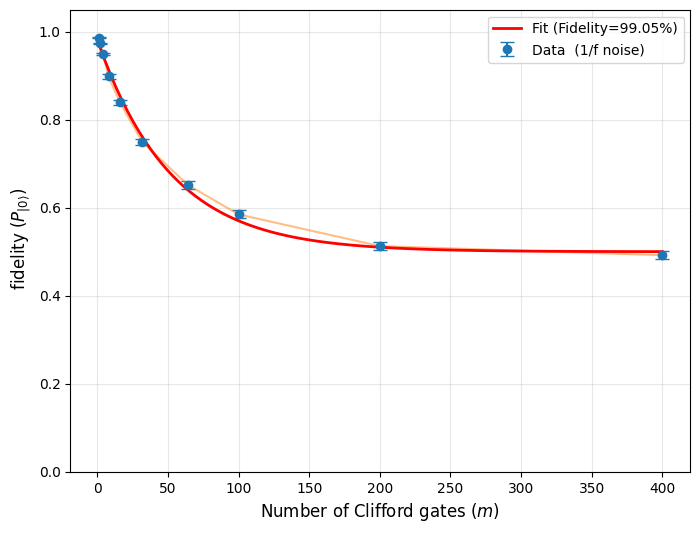

In [7]:
# Plot
plt.figure(figsize=(8, 6))
plt.errorbar(lengths, fidelities, yerr=fidelity_err, fmt='o', capsize=5, label='Data  (1/f noise)')
plt.plot(lengths, fidelities, '-', alpha=0.5)
plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'Fit (Fidelity={fidelity_per_gate:.2%})')

plt.xlabel("Number of Clifford gates ($m$)", fontsize=12)
plt.ylabel(" fidelity ($P_{|0\\rangle}$)", fontsize=12)
#plt.title(f"Randomized Benchmarking (Simulation)\n$\\sigma_{{noise}}$={sigma_noise} rad/s, $t_{{gate}}$={t_gate} $\\mu s$", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
def run_rb(noise_mode):
    """noise_mode = 'pink' (correlated, windows of the long trace) or 'white' (independent per gate).
    Both are matched to the same per-gate variance, so the only difference is the CORRELATION."""
    curve, err = [], []
    for m in lengths:
        survivals = []
        for seed in range(n_seeds):
            sequence_indices = rng.integers(0, len(clifford_group), m)
            U_ideal = I
            for idx in sequence_indices:
                U_ideal = clifford_group[idx] @ U_ideal
            U_recovery = U_ideal.conj().T

            if noise_mode == 'pink':
                start_t = rng.integers(0, Nt_total - m - 2)
                noise_segment = noise_trace[start_t : start_t + m + 1]
            elif noise_mode == 'white':
                noise_segment = rng.normal(0.0, sigma_realised, m + 1) #same variance, no correlation
            else: # quasi-static: ONE frozen draw for the whole sequence, the maximally correlated limit
                noise_segment = np.full(m + 1, rng.normal(0.0, sigma_realised))

            psi = np.array([1, 0], dtype=complex)
            for k, idx in enumerate(sequence_indices):
                psi = rotation_matrix(Z, noise_segment[k] * t_gate) @ (clifford_group[idx] @ psi)
            psi = rotation_matrix(Z, noise_segment[m] * t_gate) @ (U_recovery @ psi)
            survivals.append(np.abs(psi[0])**2)

        curve.append(np.mean(survivals))
        err.append(np.std(survivals) / np.sqrt(n_seeds))
    return np.array(curve), np.array(err)


def fit_rb(curve):
    (A, p), _ = curve_fit(lambda m, A, p: A * p**m + 0.5, lengths, curve, p0=[0.5, 0.99])
    return A, p, 1 - (A + 0.5)   # A, p, spam


for mode in ['white', 'pink']:
    curve, _ = run_rb(mode)
    A, p, spam = fit_rb(curve)
    print(f"{mode:6s} : p = {p:.4f}  F = {(p+1)/2:.2%}  SPAM = {spam:+.4f}   "
          f"(prediction p = {p_predicted:.4f})")

white  : p = 0.9726  F = 98.63%  SPAM = +0.0016   (prediction p = 0.9716)
pink   : p = 0.9819  F = 99.10%  SPAM = +0.0168   (prediction p = 0.9716)


white        : p = 0.9719  F = 98.59%  SPAM = +0.0011   (prediction p = 0.9716, F = 98.58%)
pink         : p = 0.9819  F = 99.09%  SPAM = +0.0185   (prediction p = 0.9716, F = 98.58%)
quasistatic  : p = 0.9922  F = 99.61%  SPAM = +0.0564   (prediction p = 0.9716, F = 98.58%)


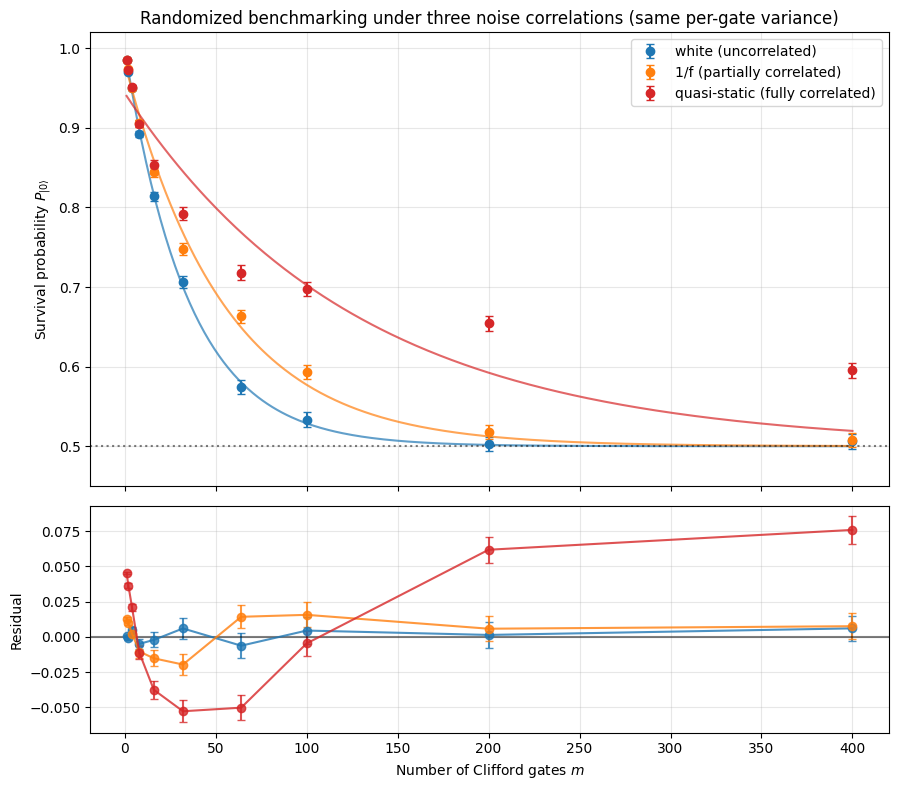

In [9]:
# Three noise types at MATCHED per-gate variance: the only thing that changes is the correlation between successive gates. 
#Standard RB assumes those errors are independent, so the single exponential A*p^m + 0.5 should only be exact in the white case.

results = {}
for mode in ['white', 'pink', 'quasistatic']:
    curve, err = run_rb(mode)
    A, p, spam = fit_rb(curve)
    results[mode] = dict(curve=curve, err=err, A=A, p=p, spam=spam)
    print(f"{mode:12s} : p = {p:.4f}  F = {(p+1)/2:.2%}  SPAM = {spam:+.4f}   "
          f"(prediction p = {p_predicted:.4f}, F = {(p_predicted+1)/2:.2%})")

m_smooth = np.linspace(lengths[0], lengths[-1], 300)
colors = {'white': 'tab:blue', 'pink': 'tab:orange', 'quasistatic': 'tab:red'}
labels = {'white': 'white (uncorrelated)', 'pink': '1/f (partially correlated)',
          'quasistatic': 'quasi-static (fully correlated)'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1.5]})

for mode, r in results.items():
    ax1.errorbar(lengths, r['curve'], yerr=r['err'], fmt='o', capsize=3,
                 color=colors[mode], label=labels[mode])
    ax1.plot(m_smooth, rb_decay_function(m_smooth, r['A'], r['p'], 0.5), '-',
             color=colors[mode], alpha=0.7)

ax1.axhline(0.5, color='k', ls=':', alpha=0.5)
ax1.set_ylabel(r'Survival probability $P_{|0\rangle}$')
ax1.set_title('Randomized benchmarking under three noise correlations (same per-gate variance)')
ax1.set_ylim(0.45, 1.02)
ax1.legend()
ax1.grid(True, alpha=0.3)

# The residuals are the real evidence: if the single exponential were the right model, they would scatter randomly around zero. 
# Systematic curvature means the decay is NOT a single exponential,which is exactly what correlated errors produce (a mixture of exponentials with different rates).
for mode, r in results.items():
    fit = rb_decay_function(lengths, r['A'], r['p'], 0.5)
    ax2.errorbar(lengths, r['curve'] - fit, yerr=r['err'], fmt='o-', capsize=3,
                 color=colors[mode], alpha=0.8)

ax2.axhline(0.0, color='k', ls='-', alpha=0.5)
ax2.set_xlabel('Number of Clifford gates $m$')
ax2.set_ylabel('Residual')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### About the plots

The white-noise curve is the control. Errors at successive gates are independent, which is exactly what the standard analysis assumes, and the fit is essentially perfect: $p$ agrees with the analytic prediction to within $10^{-4}$, and the SPAM offset is an order of magnitude smaller than in the correlated cases, as it should be since the simulation has no preparation or measurement error by construction.

The other two depart, and the mechanism is the same in both. When the noise is correlated, the detuning is nearly frozen over a sequence, so every gate in that sequence sees the same error and that sequence decays at its own rate $p_i$. Different sequences draw different detunings, so the measured curve is a sum of exponentials with different rates, and a sum of exponentials is not an exponential:

$$\frac{1}{N}\sum_i p_i^{\,m} \;\neq\; \bar{p}^{\,m}$$

This is why the fit fails: the function being fitted is simply not the function the data follows. The average per-gate error is unchanged — the comparison is made at matched variance — but the *spread* of rates across sequences is not, and it is that spread which produces the mismatch. The fast-decaying sequences die early while the slow ones survive, so the curve falls quickly at first and then flattens into a long tail dominated by the sequences that happened to draw a small detuning.

The residuals make this visible. For quasi-static noise they are positive at small $m$, negative at intermediate $m$, and positive again at large $m$ — the characteristic signature of forcing a single exponential onto a mixture. The fitted curve is a compromise: it cannot be steep enough to follow the initial drop and shallow enough to follow the tail, so it passes above the data in the middle and below it at both ends. Structured residuals of this kind, as opposed to random scatter, are the diagnostic that the model is wrong rather than merely noisy. The consequences for the fitted parameters follow from the same compromise: $p$ comes out too high, because the surviving slow sequences set the late-time slope, and the intercept is pulled below 1 to accommodate the fast initial fall, which the standard parameterisation reports as SPAM even though none is present. A nonzero SPAM in a model that has none is therefore itself a signature of correlated errors.

The quasi-static case is the clearest demonstration, since the detuning is frozen for the whole sequence and the spread of rates is largest. The 1/f case is the one that matters, because it is what the hardware has: the correlation is partial, the rates lie close together, and the fit still looks acceptable while returning a fidelity better than the true one. The failure is not visible in the curve — it is detectable only against the analytic prediction and the uncorrelated control.